# 实验4：区块链性能数值模拟（对应论文图4 + 图5 + 图6）

**注意：此图为数值模拟，非真实区块链测试。**

论文使用 FISCO BCOS 联盟链进行真实测试，此处用数值拟合模拟其结果。
数据点严格对齐论文中的描述。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============ 图4参数 ============
FIG4_TRANSACTIONS = np.array([10000, 50000, 100000, 200000, 300000, 400000, 500000])
FIG4_K = 0.5                  # ms per transaction

# ============ 图5参数 ============
FIG5_USERS = np.array([10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000])

# ============ 图6参数 ============
FIG6_TPS = np.array([100, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])

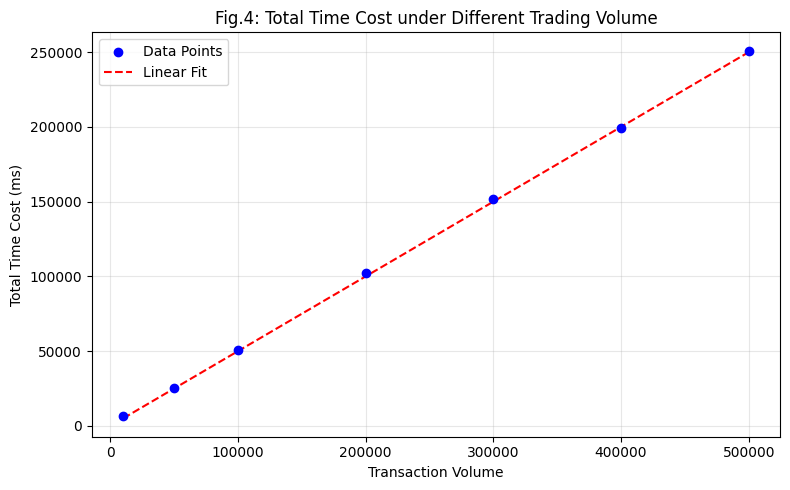

In [2]:
# 图4：不同交易量下总时间成本
np.random.seed(0)
time_cost = FIG4_K * FIG4_TRANSACTIONS
noise = np.random.normal(0, 1000, len(FIG4_TRANSACTIONS))
time_cost_noisy = np.maximum(time_cost + noise, 0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(FIG4_TRANSACTIONS, time_cost_noisy, color='blue', zorder=5, label='Data Points')
ax.plot(FIG4_TRANSACTIONS, time_cost, color='red', linestyle='--', label='Linear Fit')
ax.set_xlabel('Transaction Volume')
ax.set_ylabel('Total Time Cost (ms)')
ax.set_title('Fig.4: Total Time Cost under Different Trading Volume')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

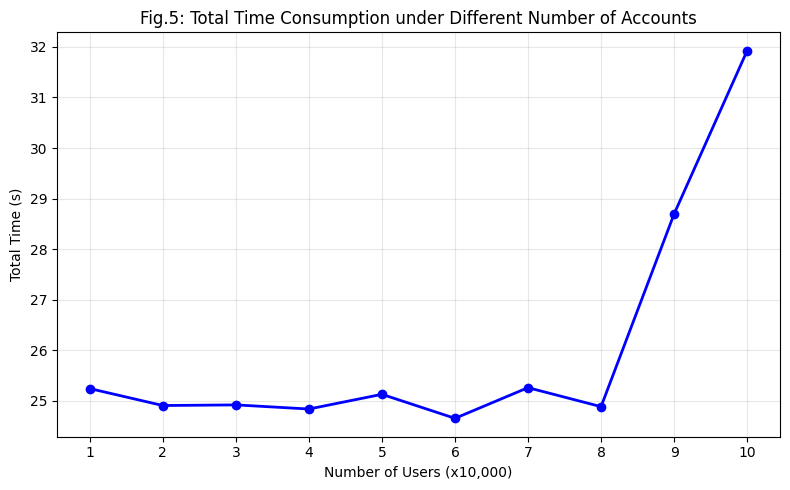

In [3]:
# 图5：不同账户数量下总耗时
np.random.seed(1)

def fig5_model(user_count):
    """模拟PBFT的O(n^2)效应"""
    result = np.zeros(len(user_count))
    for i, u in enumerate(user_count):
        if u <= 80000:
            result[i] = 25.0 + np.random.normal(0, 0.15)
        else:
            excess = (u - 80000) / 20000
            result[i] = 25.2 + excess * (32 - 25.2) + np.random.normal(0, 0.3)
    return result

time_total = fig5_model(FIG5_USERS)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(FIG5_USERS / 10000, time_total, 'b-o', linewidth=2)
ax.set_xlabel('Number of Users (x10,000)')
ax.set_ylabel('Total Time (s)')
ax.set_title('Fig.5: Total Time Consumption under Different Number of Accounts')
ax.set_xticks(FIG5_USERS / 10000)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

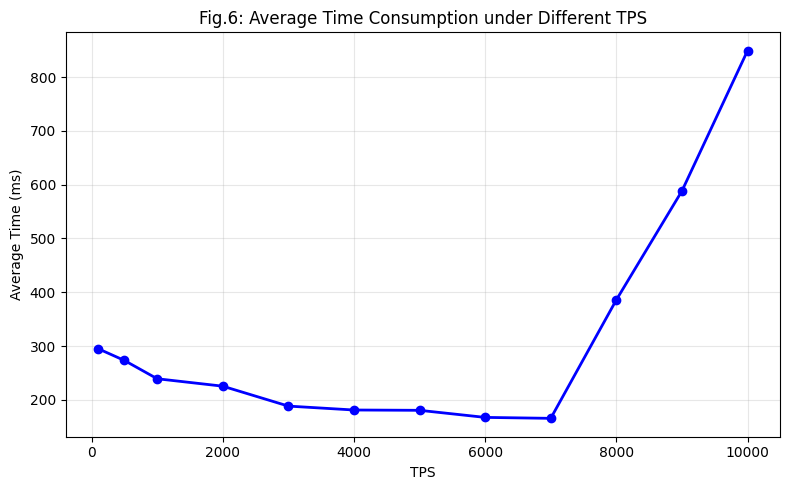

In [4]:
# 图6：不同TPS下平均耗时
np.random.seed(2)

def fig6_model(tps_values):
    """模拟TPS与平均耗时的关系"""
    result = np.zeros(len(tps_values))
    for i, t in enumerate(tps_values):
        if t <= 7000:
            result[i] = 167 + (304 - 167) * np.exp(-t / 2000) + np.random.normal(0, 5)
        elif t == 8000:
            result[i] = 395 + np.random.normal(0, 10)
        elif t == 9000:
            result[i] = 580 + np.random.normal(0, 15)
        else:
            result[i] = 803 + np.random.normal(0, 20)
    return result

avg_time = fig6_model(FIG6_TPS)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(FIG6_TPS, avg_time, 'b-o', linewidth=2)
ax.set_xlabel('TPS')
ax.set_ylabel('Average Time (ms)')
ax.set_title('Fig.6: Average Time Consumption under Different TPS')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()